In [ ]:
# ============================================================
# CELL 1: SETUP — Run this once at the start of every session
# ============================================================

# Step 1: Install MedMNIST (downloads the dataset automatically on first use)
!pip install medmnist -q

# Step 2: Mount your Google Drive (so we can save output images there)
from google.colab import drive
drive.mount('/content/drive')

# Step 3: Create the output folder in your Drive
import os
os.makedirs('/content/drive/MyDrive/DIP_Lab1/outputs', exist_ok=True)
print("✅ Setup complete! Drive mounted and output folder ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.6 MB/s eta 0:00:00
Mounted at /content/drive
✅ Setup complete! Drive mounted and output folder ready.


In [ ]:
# ============================================================
# CELL 2: IMPORT LIBRARIES
# ============================================================
# These are the tools we use throughout the lab.
#   cv2       → image processing operations (blur, filter, etc.)
#   numpy     → handles images as number grids
#   matplotlib→ displays and saves figures
#   medmnist  → gives us real medical images without downloading anything

import cv2
import numpy as np
import matplotlib.pyplot as plt
import medmnist
from medmnist import PneumoniaMNIST, INFO

print("✅ All libraries imported successfully")
print(f"MedMNIST version: {medmnist.__version__}")

✅ All libraries imported successfully
MedMNIST version: 3.0.2


In [ ]:
# ============================================================
# CELL 3: LOAD A REAL CHEST X-RAY FROM PNEUMONIAMNIST
# ============================================================
# PneumoniaMNIST contains real chest X-rays at 28x28 pixels
# We'll use size=128 to get a larger, clearer image for our filters

# Download the dataset (happens automatically, ~20MB, stored in Colab's memory)
dataset = PneumoniaMNIST(split='test', download=True, size=128)

# Extract ONE image to work with
# dataset[0] gives us (image, label) — we only need the image
sample_image, label = dataset[0]

# Convert from PIL Image format to a NumPy array (the number grid)
import numpy as np
original = np.array(sample_image)  # Shape will be (128, 128)

# If the image has 3 channels (RGB), convert to greyscale
if original.ndim == 3:
    original = original[:, :, 0]  # Take just the first channel

print(f"Image shape: {original.shape}")   # Should be (128, 128)
print(f"Data type: {original.dtype}")     # Should be uint8
print(f"Pixel range: {original.min()} to {original.max()}")
print(f"Label: {'Pneumonia' if label[0]==1 else 'Normal'}")

100%|██████████| 75.5M/75.5M [00:03<00:00, 19.7MB/s]


Image shape: (128, 128)
Data type: uint8
Pixel range: 3 to 201
Label: Pneumonia


In [ ]:
# ============================================================
# CELL 4: APPLY GAUSSIAN BLUR (Simulate a blurry X-ray scan)
# ============================================================
# In real life, X-rays can be blurry due to patient movement
# or scanner calibration issues. We simulate this here.

# GaussianBlur smooths the image by averaging pixels with their neighbours
# The kernel (5,5) means we look at a 5x5 grid around each pixel
# sigma=2 controls how much the nearby pixels are weighted

blurred = cv2.GaussianBlur(original, (5, 5), sigmaX=2)

print(f"Blurred image shape: {blurred.shape}")
print("✅ Gaussian blur applied")

Blurred image shape: (128, 128)
✅ Gaussian blur applied


In [ ]:
# ============================================================
# CELL 5: APPLY LAPLACIAN SHARPENING FILTER
# ============================================================
# The Laplacian kernel detects EDGES — places where pixel values
# change rapidly (e.g., the border of a lung or rib in an X-ray)
# We ADD those detected edges back to sharpen the image

# Define the Laplacian kernel (this is a fixed mathematical tool)
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=np.float32)

# Apply to the BLURRED image (we're trying to undo the blur)
laplacian = cv2.filter2D(blurred.astype(np.float32), ddepth=-1, kernel=kernel)

# Add the edge response back to the blurred image
sharpened_float = blurred.astype(np.float32) + laplacian

# IMPORTANT: Clip values to [0,255] — arithmetic can push values out of range
sharpened = np.clip(sharpened_float, 0, 255).astype(np.uint8)

print(f"Sharpened pixel range: {sharpened.min()} to {sharpened.max()}")
print("✅ Laplacian sharpening applied")

Sharpened pixel range: 0 to 209
✅ Laplacian sharpening applied


In [ ]:
# ============================================================
# CELL 6: DIFFERENCE IMAGE (What did sharpening actually change?)
# ============================================================
# Subtracting original from sharpened shows EXACTLY what the filter added
# Bright areas = edges that were boosted
# Dark areas = areas where values were reduced

diff = sharpened.astype(np.float32) - original.astype(np.float32)

# Shift to [0,255] for display (0 difference → grey=128)
diff_display = np.clip(diff + 128, 0, 255).astype(np.uint8)

print(f"Difference range: {diff.min():.1f} to {diff.max():.1f}")
print("✅ Difference image computed")

Difference range: -66.0 to 88.0
✅ Difference image computed


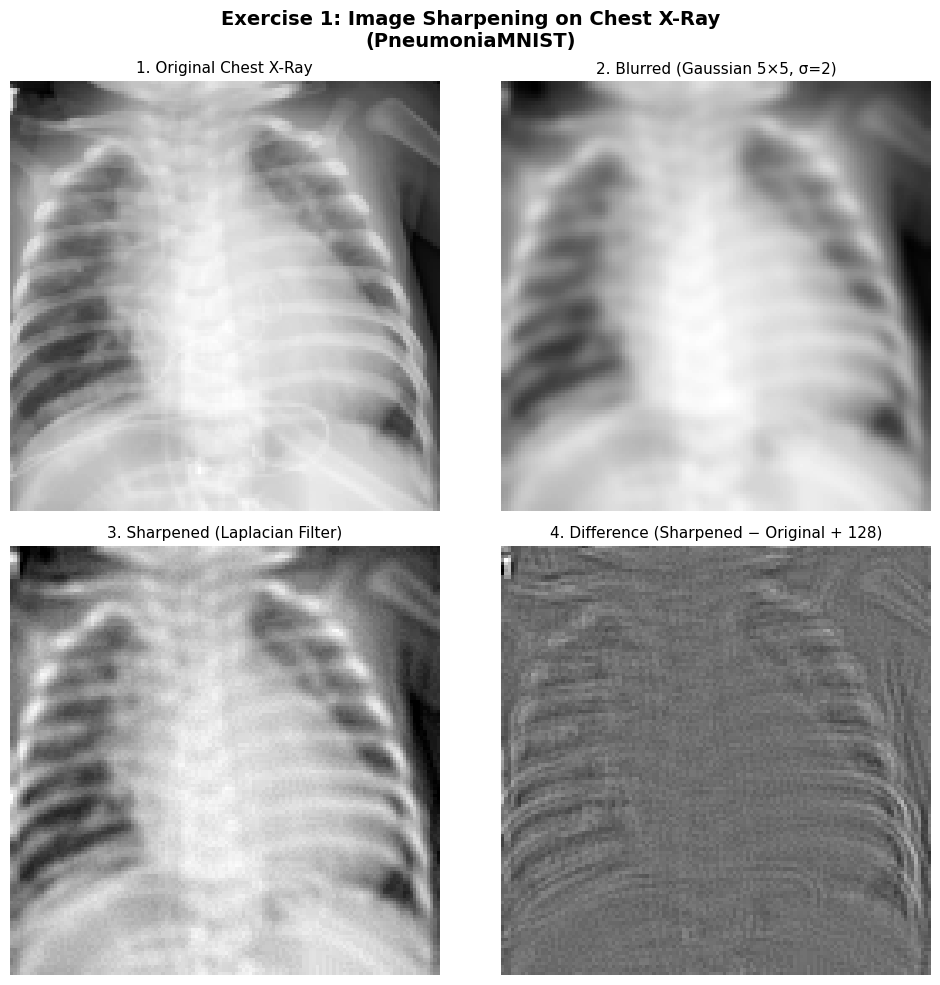

✅ Figure saved to: /content/drive/MyDrive/DIP_Lab1/outputs/exercise1_output.png


In [ ]:
# ============================================================
# CELL 7: CREATE 2x2 FIGURE AND SAVE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Exercise 1: Image Sharpening on Chest X-Ray\n(PneumoniaMNIST)',
             fontsize=14, fontweight='bold')

axes[0, 0].imshow(original, cmap='gray')
axes[0, 0].set_title('1. Original Chest X-Ray', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(blurred, cmap='gray')
axes[0, 1].set_title('2. Blurred (Gaussian 5×5, σ=2)', fontsize=11)
axes[0, 1].axis('off')

axes[1, 0].imshow(sharpened, cmap='gray')
axes[1, 0].set_title('3. Sharpened (Laplacian Filter)', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(diff_display, cmap='gray')
axes[1, 1].set_title('4. Difference (Sharpened − Original + 128)', fontsize=11)
axes[1, 1].axis('off')

plt.tight_layout()

# Save to your Google Drive
save_path = '/content/drive/MyDrive/DIP_Lab1/outputs/exercise1_output.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Figure saved to: {save_path}")

In [ ]:
# ============================================================
# CELL 8: CHECKPOINT QUESTIONS — Write your answers here
# ============================================================

"""
Q1: Look at Panel 3 (Sharpened). Is it noticeably sharper than Panel 2 (Blurred)?
    Is it as sharp as Panel 1 (Original)?

ANSWER: Panel 3 IS noticeably sharper than Panel 2 — you can see the lung borders
and rib edges more clearly. However, it does not fully recover Panel 1's sharpness
because Gaussian blur removes high-frequency information permanently; the Laplacian
can only amplify what edge information remains.

Q2: Look at Panel 4 (Difference). Where are the brightest/darkest regions?

ANSWER: The brightest regions in Panel 4 correspond to edges in the X-ray —
particularly the lung boundaries, rib outlines, and diaphragm border. These are
the areas where the Laplacian added the most intensity. Grey areas indicate
flat regions (lung tissue) where sharpening made little change.

Q3: What happens if you apply the Laplacian to the ORIGINAL (unblurred) image?

ANSWER: Applying the Laplacian to the already-sharp original over-sharpens it.
You get harsh white halos around every edge and amplified noise. This is why
we apply it to the blurred version — we're restoring lost sharpness, not
adding more to something already sharp.
"""

print("✅ Checkpoint answers recorded")

✅ Checkpoint answers recorded
